In [141]:
import pandas as pd
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Forme :", df.shape)
print(df.dtypes)
df.head()

Forme : (7043, 21)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [142]:
def audit_qualite(df):
    print("\nForme (lignes, colonnes) :", df.shape)
    manquants = df.isna().sum()
    # print(manquants)
    pourcentage = (df.isna().mean() * 100).round(1)
    # print(pourcentage)
    resume = pd.DataFrame({"manquants": manquants, "pourcent": pourcentage}).sort_values("pourcent", ascending=False)
    if(len(resume[resume["manquants"] > 0])==0):
        print("Manquants détectés : 0 colonne")
    else:
        print(resume[resume["manquants"] > 0].sort_values("pourcent", ascending=False))
    
    total = len(df)
    if total == 0:
        print("Dataset vide")
        return
    churn_counts = df["Churn"].value_counts().reindex(["No", "Yes"], fill_value=0)
    churn_pct = (churn_counts / total * 100).round(1)

    print(f"Cible Churn : No={churn_counts['No']} ({churn_pct['No']}%), Yes={churn_counts['Yes']} ({churn_pct['Yes']}%)")

    if churn_pct.max() > 70:
        print("Attention : cible déséquilibrée")
    


In [143]:
#tous le dataset
audit_qualite(df)


Forme (lignes, colonnes) : (7043, 21)
Manquants détectés : 0 colonne
Cible Churn : No=5174 (73.5%), Yes=1869 (26.5%)
Attention : cible déséquilibrée


In [144]:
#dataset filtré churn yes
df_filtered = df[df["Churn"] == "Yes"]
audit_qualite(df_filtered)



Forme (lignes, colonnes) : (1869, 21)
Manquants détectés : 0 colonne
Cible Churn : No=0 (0.0%), Yes=1869 (100.0%)
Attention : cible déséquilibrée


In [145]:
#dataset filtré churn no
df_filtered = df[df["Churn"] == "No"]
audit_qualite(df_filtered)



Forme (lignes, colonnes) : (5174, 21)
Manquants détectés : 0 colonne
Cible Churn : No=5174 (100.0%), Yes=0 (0.0%)
Attention : cible déséquilibrée


In [146]:
def reparer_total_charges(df):
    
    import numpy as np
    s = df["TotalCharges"].astype(str).str.strip()

    # 1) colonne 100% non numérique -> on refuse
    converted = pd.to_numeric(s, errors="coerce")
    if converted.notna().sum() == 0:
        raise ValueError("TotalCharges est entièrement non numérique, conversion refusée")

    # 2) repérer les valeurs suspectes type 29,90
    suspects = s.str.match(r"^\d+,\d+$", na=False)
    if suspects.any():
        exemples = df.loc[suspects, "TotalCharges"].head(5).tolist()
        raise ValueError(f"Format numérique invalide détecté dans TotalCharges : {exemples}")
    
    totalCharges = df["TotalCharges"]
    totalChargesNum = pd.to_numeric(df["TotalCharges"], errors="coerce")
    print("Trous avant :", int(totalCharges.isna().sum()))
    print("Trous après conversion :", int(np.isnan(totalChargesNum).sum()))
    print(f"Pourcentage : {int(np.isnan(totalChargesNum).sum())/len(totalChargesNum)*100:.2f}")

    print("Imputation simple")
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy="median")
    df1 = pd.DataFrame({"TotalCharges": totalChargesNum})
    totalCharge_rempli = imputer.fit_transform(df1[["TotalCharges"]])
    print("Valeur utilisée (médiane) :", round(imputer.statistics_[0], 1))
    print(f"Avant : moyenne={df1['TotalCharges'].mean():.2f}, écart-type={df1['TotalCharges'].std():.2f}")
    print(f"Après : moyenne={pd.Series(totalCharge_rempli.ravel()).mean():.2f}, écart-type={pd.Series(totalCharge_rempli.ravel()).std():.2f}")
    print("Suppression ligne vide")
    df_sans_lignes = pd.DataFrame({"TotalCharges": totalChargesNum}).dropna(subset=["TotalCharges"])
    print(f"Avant : moyenne={df1['TotalCharges'].mean():.2f}, écart-type={df1['TotalCharges'].std():.2f}")
    print(f"Après : moyenne={pd.Series(df_sans_lignes['TotalCharges']).mean():.2f}, écart-type={pd.Series(df_sans_lignes['TotalCharges']).std():.2f}")

    if (int(np.isnan(totalChargesNum).sum())/len(totalChargesNum)*100 < 1):
        df["TotalCharges"] = df_sans_lignes["TotalCharges"]
    else:
        df["TotalCharges"] = totalCharge_rempli.ravel()

    return df


In [147]:
df = reparer_total_charges(df)

Trous avant : 0
Trous après conversion : 11
Pourcentage : 0.16
Imputation simple
Valeur utilisée (médiane) : 1397.5
Avant : moyenne=2283.30, écart-type=2266.77
Après : moyenne=2281.92, écart-type=2265.27
Suppression ligne vide
Avant : moyenne=2283.30, écart-type=2266.77
Après : moyenne=2283.30, écart-type=2266.77


In [148]:
def encoder_features(df):
    colonnes_categorielles = df.select_dtypes(include=["object", "string"]).columns.tolist()
    print(colonnes_categorielles)
    if "customerID" in colonnes_categorielles:
        colonnes_categorielles.remove("customerID")

    colonnes_binaires = [col for col in colonnes_categorielles if df[col].nunique(dropna=True) == 2]
    colonnes_nominales = [col for col in colonnes_categorielles if col not in colonnes_binaires]

    print("Colonnes binaires :", colonnes_binaires)
    print("Colonnes nominales :", colonnes_nominales)

    for col in colonnes_binaires:
        valeurs = df[col].dropna().unique().tolist()
        if set(valeurs) == {"Yes", "No"} or set(valeurs) == {"No", "Yes"}:
            df[col] = df[col].map({"No": 0, "Yes": 1})
        else:
            df[col] = pd.Categorical(df[col]).codes

    if colonnes_nominales:
        df = pd.get_dummies(df, columns=colonnes_nominales, prefix=colonnes_nominales, dtype=int)
    ids = df["customerID"]
    df = df.drop(columns=["customerID"])
    print(df.shape)
    return df


In [149]:
df = encoder_features(df)

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
Colonnes binaires : ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
Colonnes nominales : ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
(7043, 41)


In [150]:
def detecter_outliers_iqr(df, colonne):
    serie = pd.to_numeric(df[colonne], errors="coerce")
    valeurs = serie.dropna()
    if valeurs.empty:
        raise ValueError(f"La colonne {colonne} ne contient aucune valeur numérique exploitable.")

    q1 = valeurs.quantile(0.25)
    q3 = valeurs.quantile(0.75)
    iqr = q3 - q1
    borne_basse = q1 - 1.5 * iqr
    borne_haute = q3 + 1.5 * iqr
    masque_outliers = (serie < borne_basse) | (serie > borne_haute)
    nombre_outliers = int(masque_outliers.sum())

    print(f"Colonne : {colonne}")
    print(f"Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")
    print(f"Bornes IQR : [{borne_basse:.2f}, {borne_haute:.2f}]")
    print(f"Outliers détectés : {nombre_outliers}")

    if nombre_outliers == 0:
        print("Décision : aucun outlier à traiter dans cette colonne.")
    else:
        if "Churn" in df.columns:
            churn_total = int(df["Churn"].eq("Yes").sum())
            churn_perdus = int(df.loc[masque_outliers, "Churn"].eq("Yes").sum())
            pct_churn_perdus = (churn_perdus / churn_total * 100) if churn_total else 0
            print(f"Churn perdus si suppression : {churn_perdus} sur {churn_total} ({pct_churn_perdus:.1f}%)")
            if pct_churn_perdus >= 5:
                print("Alerte : supprimer ces outliers ferait perdre au moins 5% des résiliations.")
            print("Décision : ne pas supprimer automatiquement sans vérification métier, car un outlier peut être une valeur réelle précieuse.")
        else:
            print("Décision : ne pas supprimer automatiquement sans vérification métier.")

    return borne_basse, borne_haute, nombre_outliers


In [151]:
detecter_outliers_iqr(df, "tenure")

Colonne : tenure
Q1=9.00, Q3=55.00, IQR=46.00
Bornes IQR : [-60.00, 124.00]
Outliers détectés : 0
Décision : aucun outlier à traiter dans cette colonne.


(np.float64(-60.0), np.float64(124.0), 0)

In [152]:
detecter_outliers_iqr(df, "MonthlyCharges")

Colonne : MonthlyCharges
Q1=35.50, Q3=89.85, IQR=54.35
Bornes IQR : [-46.02, 171.38]
Outliers détectés : 0
Décision : aucun outlier à traiter dans cette colonne.


(np.float64(-46.02499999999999), np.float64(171.375), 0)

In [153]:
detecter_outliers_iqr(df, "TotalCharges")


Colonne : TotalCharges
Q1=401.45, Q3=3794.74, IQR=3393.29
Bornes IQR : [-4688.48, 8884.67]
Outliers détectés : 0
Décision : aucun outlier à traiter dans cette colonne.


(np.float64(-4688.481250000001), np.float64(8884.66875), 0)

In [154]:

def rapport_multicolinearite(df, colonnes_num=None):
    import numpy as np
    import seaborn as sns
    import matplotlib.pyplot as plt
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    if colonnes_num is None:
        colonnes_num = df.select_dtypes(include=["number"]).columns.tolist()
        if "Churn" in colonnes_num:
            colonnes_num.remove("Churn")

    if len(colonnes_num) < 2:
        raise ValueError("Il faut au moins deux colonnes numériques pour calculer les corrélations et les VIF.")

    data = df[colonnes_num].apply(pd.to_numeric, errors="coerce").dropna().copy()
    if data.empty:
        raise ValueError("Aucune ligne exploitable après nettoyage des colonnes numériques.")

    corr = data.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr,
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        linecolor="white",
        square=True,
        cbar_kws={"shrink": 0.8},
    )
    plt.title("Heatmap des corrélations")
    plt.tight_layout()
    plt.show()

    X = data.loc[:, ~data.columns.duplicated()].copy()
    if X.shape[1] < 2:
        raise ValueError("Il faut au moins deux colonnes distinctes pour calculer les VIF.")

    vif_rows = []
    values = X.to_numpy()
    for i, col in enumerate(X.columns):
        try:
            vif = variance_inflation_factor(values, i)
        except Exception:
            vif = np.inf
        vif_rows.append({"colonne": col, "VIF": vif})

    vif_df = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)
    print(vif_df)

    columns_to_watch = vif_df.loc[vif_df["VIF"].replace([np.inf, -np.inf], np.nan) > 5, "colonne"].tolist()
    print("Colonnes avec VIF > 5 :", columns_to_watch)

    if {"TotalCharges", "MonthlyCharges", "tenure"}.issubset(df.columns):
        print("Décision métier : ne pas supprimer automatiquement TotalCharges, car elle contient une information complémentaire à MonthlyCharges et à tenure.")

    return corr, vif_df


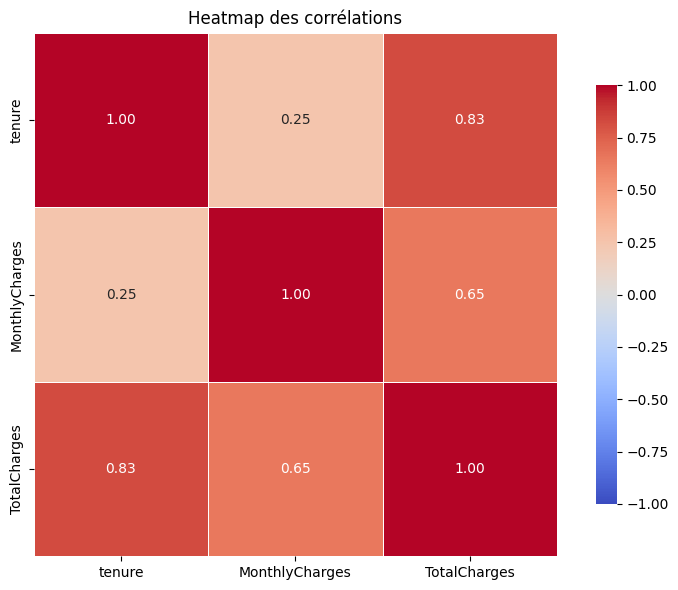

          colonne       VIF
2    TotalCharges  8.079181
0          tenure  6.332432
1  MonthlyCharges  3.361075
Colonnes avec VIF > 5 : ['TotalCharges', 'tenure']
Décision métier : ne pas supprimer automatiquement TotalCharges, car elle contient une information complémentaire à MonthlyCharges et à tenure.


(                  tenure  MonthlyCharges  TotalCharges
 tenure          1.000000        0.246862      0.825880
 MonthlyCharges  0.246862        1.000000      0.651065
 TotalCharges    0.825880        0.651065      1.000000,
           colonne       VIF
 2    TotalCharges  8.079181
 0          tenure  6.332432
 1  MonthlyCharges  3.361075)

In [155]:

rapport_multicolinearite(df, ["tenure", "MonthlyCharges", "TotalCharges"])